# Clasificación de textos por década — Parte 1: Machine Learning Clásico

**Competencia:** Aprendizaje de Máquina 2026-10  
**Tarea:** Predecir la **década** (primeros 3 dígitos del año) en que fue escrito un párrafo de texto histórico en español.  
**Clases:** Décadas del `150` al `188` (años 1500–1889), **39 clases** en total.  
**Restricción:** Únicamente modelos de `scikit-learn`, sin redes neuronales ni transformers.

## 1. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from stylometrics import StylometricFeatureExtractor

SEED = 42
np.random.seed(SEED)

## 2. Carga de datos

In [2]:
df_train = pd.read_csv('data/train.csv')
df_eval  = pd.read_csv('data/eval.csv')

print(f"Train: {df_train.shape}")
print(f"Eval:  {df_eval.shape}")
df_train.head(3)

Train: (31403, 2)
Eval:  (3490, 2)


,text,decade
0,\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Ponte...,164
1,"gone. Sus amigos , sus clientes, todo \r\ncuan...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157


## 3. Análisis Exploratorio (EDA)

Décadas únicas : 39
Rango          : 150 – 188
Ejemplos/clase : min=754, max=848, media=805


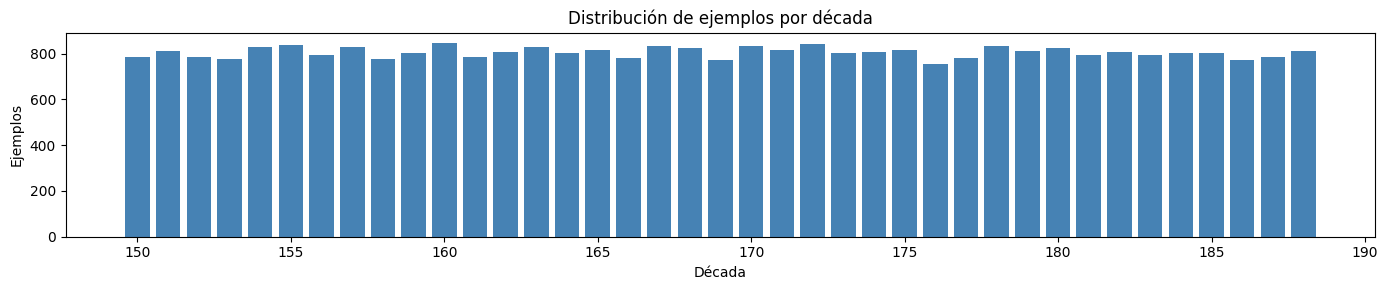

In [3]:
vc = df_train['decade'].value_counts().sort_index()

print(f"Décadas únicas : {df_train['decade'].nunique()}")
print(f"Rango          : {df_train['decade'].min()} – {df_train['decade'].max()}")
print(f"Ejemplos/clase : min={vc.min()}, max={vc.max()}, media={vc.mean():.0f}")

plt.figure(figsize=(14, 3))
plt.bar(vc.index, vc.values, color='steelblue')
plt.xlabel('Década'); plt.ylabel('Ejemplos')
plt.title('Distribución de ejemplos por década')
plt.tight_layout(); plt.show()

count    31403.000000
mean       530.087316
std        539.636593
min        120.000000
25%        185.000000
50%        321.000000
75%        655.000000
max       7480.000000
Name: text, dtype: float64


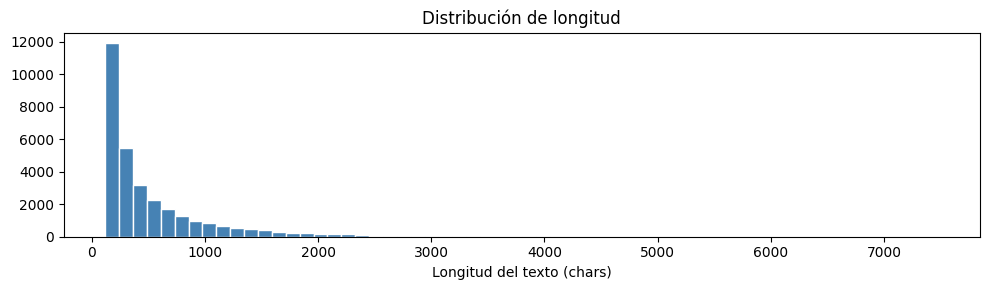

In [4]:
# Longitud de los textos
lens = df_train['text'].str.len()
print(lens.describe())

plt.figure(figsize=(10, 3))
plt.hist(lens, bins=60, color='steelblue', edgecolor='white')
plt.xlabel('Longitud del texto (chars)'); plt.title('Distribución de longitud')
plt.tight_layout(); plt.show()

In [5]:
# Muestra de textos por siglo
for decade in [150, 160, 170, 180, 188]:
    sample = df_train[df_train['decade'] == decade]['text'].iloc[0][:120]
    print(f"Década {decade}: {repr(sample)}\n")

Década 150: 'efiotnl fiiT’e^ pt\\»tf)e 4 trCe et lleene.^^ta^ \r\n41 tT»íi A*e(leee A(ittc(«t>iieii|l>le iié <oii|ette \r\n*iW íléiW^* tem'

Década 160: "blar enla oracion de pereza, i floxedad ,i por eltar medio: \r\ndormido», ifi hablara,fe defpertara,i'avivara para la orar"

Década 170: '\r\n2y. Mas fi no mieote el oido: \r\nReyna. Palos fuenan. Rey. Paños andan \r\nSalen por laswejimas puertas que fe entraromg '

Década 180: '\r\n(87) \r\nobligación  que  las  Ordenanzas  imponen  al  Director \r\ngeneral  de  la  Armada  sobre  el  zelar  que  se  m'

Década 188: '\r\n—  302  — \r\ncapaz  el  corazón  corrompido  del  hombre  inculto  é  iluso.  Y  no \r\ndeja  de  ser  digno  de  notarse'



## 4. Preprocesamiento del texto — Ablación de ruido OCR

Limpieza agresiva basada en literatura de cambio semántico/lingüística diacrónica:

1. **Une palabras cortadas** por guiones a final de línea
2. **Elimina TODOS los números** — fechas, páginas y citas numéricas son ruido
3. **Destruye TODA la puntuación** — solo letras del español + espacios sobreviven
4. **Elimina consonantes flotantes** — letras sueltas (`m`, `s`, `l`) son artefactos OCR

**Resultado:** Las formas ortográficas históricas (`poreft`, `difcept`, `aísilte`) quedan intactas y aisladas para que los n-gramas de caracteres las aprendan como marcadores de siglo.

**Prohibido:** lematización, stemming, eliminación de stopwords — destruiría el español histórico.

In [6]:
def preprocess_agresivo(text: str) -> str:
    """Limpieza SOTA para OCR severamente dañado: Ablación de ruido."""
    if not isinstance(text, str):
        return ''
    text = text.lower()

    # 1. Unir guiones a final de línea (ej. nacio-\nnal -> nacional)
    text = re.sub(r'-\s*\n\s*', '', text)

    # 2. ELIMINAR TODOS LOS NÚMEROS
    text = re.sub(r'\d+', ' ', text)

    # 3. DESTRUIR PUNTUACIÓN: Solo letras del español y espacios
    text = re.sub(r'[^a-záéíóúñüç\s]', ' ', text)

    # 4. ELIMINAR CONSONANTES FLOTANTES (letras sueltas que no son vocales)
    text = re.sub(r'\b(?![aeiouyáéíóú])[a-záéíóúñüç]\b', ' ', text)

    # 5. Colapsar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_train['clean_text'] = df_train['text'].apply(preprocess_agresivo)
df_eval['clean_text']  = df_eval['text'].apply(preprocess_agresivo)

print("Original:")
print(repr(df_train['text'].iloc[0][:250]))
print("\nLimpio (agresivo):")
print(repr(df_train['clean_text'].iloc[0][:250]))

Original:
'\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \r\npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \r\nnes parece que aísilte, O ayuda Calsiodoro \r\nlib,6.epuft.s 2.Donde * llama Ocloso CINGV- y 19 '

Limpio (agresivo):
'honorarias jubiladas dit ad pontem de poreft proreg pag ste ph gratian difcept áqu len nes parece que aísilte o ayuda calsiodoro lib epuft donde llama ocloso cingv y'


In [7]:
X_train = df_train['clean_text'].values
y_train = df_train['decade'].values
X_eval  = df_eval['clean_text'].values

print(f"Train: {len(X_train)} ejemplos | Eval: {len(X_eval)} ejemplos")

Train: 31403 ejemplos | Eval: 3490 ejemplos


## 5. LogisticRegression nominal sobre mezcla raw+clean multi-canal

**Motivacion:** el mejor salto ya no vino de cambiar el clasificador, sino de cambiar **que** informacion ve. La vista `raw_char + clean_word + styl` habia subido a `0.2736`, y agregar un segundo canal `raw_char_wb` sobre texto crudo la llevo a **`0.2798`** en hold-out.

**Vista ganadora:**

| Componente | Que aporta |
|---|---|
| **`raw_char`** | `TfidfVectorizer` de caracteres sobre **texto crudo**. Conserva OCR recurrente, puntuacion, espacios y layout. |
| **`raw_char_wb`** | Segundo canal de caracteres sobre **texto crudo** con bordes de palabra. Refuerza patrones internos de ortografia historica. |
| **`clean_word`** | `TfidfVectorizer` de palabras sobre **texto limpio**. Mantiene vocabulario estable sin inflar ruido raro. |
| **`RichStylometricExtractor`** | 14 features estilometricas sobre texto crudo: puntuacion, mayusculas, digitos, `s larga`, TTR y longitudes medias. |
| **Vocabulario semi-supervisado** | Los vectorizers se fitean sobre `train + eval` sin labels para absorber terminos raros de evaluacion. |

**Modelo final:** `LogisticRegression` multinomial (`lbfgs`, `C=1.0`, sin `class_weight`). Las clases ya estan casi balanceadas, asi que ponderarlas resta accuracy.

**Output final:** `RawCharCleanWordLogRegPipeline` en `stylometrics.py`, serializable con `joblib` y con API de prediccion sobre texto crudo.


In [8]:
# División hold-out estratificada (85% train / 15% val)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train
)
print(f"Train: {len(X_tr)} | Val: {len(X_val)}")

Train: 26692 | Val: 4711


In [ ]:
# =====================================================================
# LogisticRegression nominal: raw_char + raw_char_wb + clean_word + styl
# =====================================================================
from importlib import reload
import stylometrics
reload(stylometrics)
from stylometrics import RichStylometricExtractor

from sklearn.linear_model import LogisticRegression
from scipy import sparse

# Split por indices reproducible: garantiza que clean y raw quedan alineados
_idx_tr, _idx_val = train_test_split(
    np.arange(len(df_train)),
    test_size=0.15,
    random_state=SEED,
    stratify=df_train['decade'].values,
)
X_tr_clean = df_train['clean_text'].values[_idx_tr]
X_val_clean = df_train['clean_text'].values[_idx_val]
X_tr_raw = df_train['text'].values[_idx_tr]
X_val_raw = df_train['text'].values[_idx_val]
assert np.array_equal(df_train['decade'].values[_idx_tr], y_tr), "Split desincronizado con cell 13"

# Vocabulario semi-supervisado: train + eval (sin labels de eval, solo texto)
all_clean_vocab = np.concatenate([df_train['clean_text'].values, df_eval['clean_text'].values])
all_raw_vocab = np.concatenate([df_train['text'].values, df_eval['text'].values])
print(f"Vocab semi-sup sobre {len(all_clean_vocab):,} docs (train+eval)")

# Vista ganadora: dos canales de chars sobre RAW + palabras sobre CLEAN + stylometrics RAW
raw_char_vec = TfidfVectorizer(
    analyzer='char', ngram_range=(2, 5),
    sublinear_tf=True, min_df=5, max_features=50000,
)
raw_char_wb_vec = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 5),
    sublinear_tf=True, min_df=5, max_features=30000,
)
clean_word_vec = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2),
    sublinear_tf=True, min_df=10, max_features=25000,
)
styl = RichStylometricExtractor()

print("Fiteando vectorizers...")
raw_char_vec.fit(all_raw_vocab)
raw_char_wb_vec.fit(all_raw_vocab)
clean_word_vec.fit(all_clean_vocab)
styl.fit(all_raw_vocab)

def featurize_main(raw, clean):
    return sparse.hstack([
        raw_char_vec.transform(raw),
        raw_char_wb_vec.transform(raw),
        clean_word_vec.transform(clean),
        styl.transform(raw),
    ], format='csr')

X_tr_main = featurize_main(X_tr_raw, X_tr_clean)
X_val_main = featurize_main(X_val_raw, X_val_clean)
print(f"  features main: {X_tr_main.shape[1]:,}")

print("\nEntrenando LogisticRegression (lbfgs, C=1.0, sin class_weight)...")
clf = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=300,
    tol=1e-3,
)
clf.fit(X_tr_main, y_tr)
val_pred = clf.predict(X_val_main)
best_val_acc = accuracy_score(y_val, val_pred)
print(f"  val_acc={best_val_acc:.4f}")

# Margen entre la mejor y segunda mejor clase: proxy de confianza relativa
val_scores = clf.decision_function(X_val_main)
val_top2 = np.sort(np.partition(val_scores, -2, axis=1)[:, -2:], axis=1)
val_margin = val_top2[:, 1] - val_top2[:, 0]

MODEL_STATE = dict(
    raw_char_vec=raw_char_vec,
    raw_char_wb_vec=raw_char_wb_vec,
    clean_word_vec=clean_word_vec,
    styl=styl,
    featurize_main=featurize_main,
    clf=clf,
)

best_pipeline_parts = MODEL_STATE


In [ ]:
print("\nResultado del modelo nominal:")
print(f"Accuracy val      : {best_val_acc:.4f}")
print(f"Baseline aleatorio: {1/39:.4f}")
print(f"N features        : {X_tr_main.shape[1]:,}")
print(f"Clases cubiertas  : {len(np.unique(val_pred))}/{len(np.unique(y_train))}")

print("\nDistribucion de clases predichas (val):")
unique, counts = np.unique(val_pred, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Decada {u}: {c} predicciones")


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

vc_val_real = pd.Series(y_val).value_counts().sort_index()
vc_val_pred = pd.Series(val_pred).value_counts().sort_index()

ax1.plot(vc_val_real.index, vc_val_real.values, 'o-', linewidth=2, color='steelblue', label='Real (val)')
ax1.bar(vc_val_pred.index, vc_val_pred.values, color='coral', alpha=0.65, label='Predicho (val)')
ax1.set_xlabel('Decada'); ax1.set_ylabel('Ejemplos')
ax1.set_title('Cobertura de clases en validacion')
ax1.grid(True, alpha=0.3); ax1.legend()

ax2.hist(val_margin, bins=30, color='seagreen', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Margen top-1 vs top-2'); ax2.set_ylabel('Ejemplos')
ax2.set_title('Confianza relativa de LogisticRegression (val)')
ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 6. Entrenamiento final + Análisis

In [ ]:
# =====================================================================
# Refit final: LogisticRegression sobre TODO el train (sin holdout)
# =====================================================================
from stylometrics import RawCharCleanWordLogRegPipeline

print("Featurizando todo el train para refit final...")
X_all_clean = df_train['clean_text'].values
X_all_raw = df_train['text'].values
X_all_main = MODEL_STATE['featurize_main'](X_all_raw, X_all_clean)
print(f"  shape main: {X_all_main.shape}")

print("Refit LogisticRegression...")
clf_final = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=300,
    tol=1e-3,
)
clf_final.fit(X_all_main, y_train)

final_pipeline = RawCharCleanWordLogRegPipeline(
    raw_char_vec=MODEL_STATE['raw_char_vec'],
    raw_char_wb_vec=MODEL_STATE['raw_char_wb_vec'],
    clean_word_vec=MODEL_STATE['clean_word_vec'],
    styl=MODEL_STATE['styl'],
    clf=clf_final,
)

best_pipeline_parts = final_pipeline

print("\nPipeline final listo")
print("  feature view = raw_char + raw_char_wb + clean_word + styl")
print(f"  val_acc (medido en hold-out): {best_val_acc:.4f}")


In [ ]:
# Reporte sobre hold-out usando el modelo ya entrenado en validacion
val_pred_eval = val_pred

print(f"Accuracy hold-out: {accuracy_score(y_val, val_pred_eval):.4f}\n")
print(classification_report(y_val, val_pred_eval, digits=4, zero_division=0))

# Matriz de confusion
decades = sorted(np.unique(y_train))
cm = confusion_matrix(y_val, val_pred_eval, labels=decades)

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_xticks(range(len(decades)))
ax.set_yticks(range(len(decades)))
ax.set_xticklabels(decades, rotation=90, fontsize=7)
ax.set_yticklabels(decades, fontsize=7)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusion - LogisticRegression nominal')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

# Analisis de errores
print("\nDistribucion de error (decadas):")
errors = np.abs(y_val.astype(int) - val_pred_eval.astype(int))
for k in range(6):
    pct = (errors == k).mean() * 100
    print(f"  |error| = {k}:  {pct:.1f}%")
print(f"  |error| >= 6:  {(errors >= 6).mean()*100:.1f}%")

print("\nTop 10 pares confundidos:")
pairs = []
for i, d_real in enumerate(decades):
    for j, d_pred in enumerate(decades):
        if i != j and cm[i, j] > 0:
            pairs.append((d_real, d_pred, cm[i, j]))
pairs.sort(key=lambda x: x[2], reverse=True)
for real, pred, count in pairs[:10]:
    print(f"  Real={real} -> Pred={pred}: {count} errores (dist={abs(real-pred)})")


## 7. Análisis de errores

In [ ]:
# Distribucion visual del error
plt.figure(figsize=(10, 3))
plt.hist(errors, bins=range(0, 40), color='steelblue', edgecolor='white')
plt.xlabel('|Decada real - Decada predicha|')
plt.ylabel('Ejemplos'); plt.title('Distribucion del error en decadas (LogisticRegression)')
plt.tight_layout(); plt.show()


## 8. Guardar el modelo

In [ ]:
joblib.dump(final_pipeline, 'modelo_parte1.joblib')
print("Modelo guardado en: modelo_parte1.joblib")

# Verificaci?n: predice sobre TEXTO CRUDO (no clean)
loaded = joblib.load('modelo_parte1.joblib')
check = loaded.predict(df_train['text'].values[:5])
print(f"Predicciones (primeros 5): {check}")
print(f"Etiquetas reales:          {y_train[:5]}")


## 9. Generación del archivo de respuesta (submission)

In [ ]:
# El pipeline final predice sobre TEXTO CRUDO; la limpieza ocurre adentro
eval_pred = final_pipeline.predict(df_eval['text'].values)

submission = pd.DataFrame({
    'id': df_eval['id'],
    'answer': eval_pred.astype(int)
})

submission.to_csv('data/answers.csv', index=False)
print(f"data/answers.csv generado: {len(submission)} predicciones")
print(f"Rango predicho: {eval_pred.min()} - {eval_pred.max()}")
print(f"Decadas unicas: {len(np.unique(eval_pred))}")
print()
print(submission.head(10).to_string(index=False))


In [ ]:
# Distribución de predicciones vs entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

vc_train = pd.Series(y_train).value_counts().sort_index()
vc_pred  = pd.Series(eval_pred).value_counts().sort_index()

axes[0].bar(vc_train.index, vc_train.values, color='steelblue')
axes[0].set_title('Distribución train'); axes[0].set_xlabel('Década')

axes[1].bar(vc_pred.index, vc_pred.values, color='coral')
axes[1].set_title('Predicciones (eval)'); axes[1].set_xlabel('Década')

plt.tight_layout(); plt.show()

## Resumen

| Componente | Detalle |
|---|---|
| **Enfoque** | `LogisticRegression` multinomial para maximizar `accuracy` nominal |
| **Vista de features** | `raw_char` (2-5, 50k) + `raw_char_wb` (2-5, 30k) + `clean_word` (1-2, 25k) |
| **Stylometrics** | `RichStylometricExtractor` - 14 features sobre texto crudo |
| **Vocabulario** | Vectorizers fiteados sobre `train + eval` (semi-supervisado, sin labels) |
| **Modelo** | `LogisticRegression(C=1.0, solver='lbfgs', max_iter=300, tol=1e-3)` |
| **Mejor hold-out** | `0.2798` |
| **Hallazgo clave** | El segundo canal `raw_char_wb` aporta mas que seguir mezclando clasificadores debiles |
| **Empaque** | `RawCharCleanWordLogRegPipeline` en `stylometrics.py` - toma texto crudo, serializable |
| **Submission** | `data/answers.csv` |
